# Gradient Descent Visualizer
## Comparing Batch, Stochastic, and Mini-Batch GD from scratch

**Dataset:** Study Hours vs Exam Score (synthetic)  
**No scikit-learn** — everything built from scratch using NumPy

---

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt

from data.generate_data import generate_linear_data
from src.utils import preprocess
from src.config_loader import load_config
from src.linear_regression import LinearRegression
from src.optimizers.batch_gd import BatchGD
from src.optimizers.stochastic_gd import StochasticGD
from src.optimizers.minibatch_gd import MiniBatchGD

config = load_config()
print("All imports successful")
print(f"Config loaded: {list(config.keys())}")

All imports successful
Config loaded: ['data', 'model', 'visualization']


## Step 1 — Data Generation

We generate 500 synthetic data points representing:
- **X** = study hours per day (1 to 10)
- **y** = exam score (0 to 100)

True relationship: `y = 2.8 * X + 30 + noise`

The model should learn weight ≈ 2.8 and bias ≈ 30

X shape : (500, 1)
y shape : (500,)
X range : -10.00 to 20.00
y range : -1.55 to 91.70


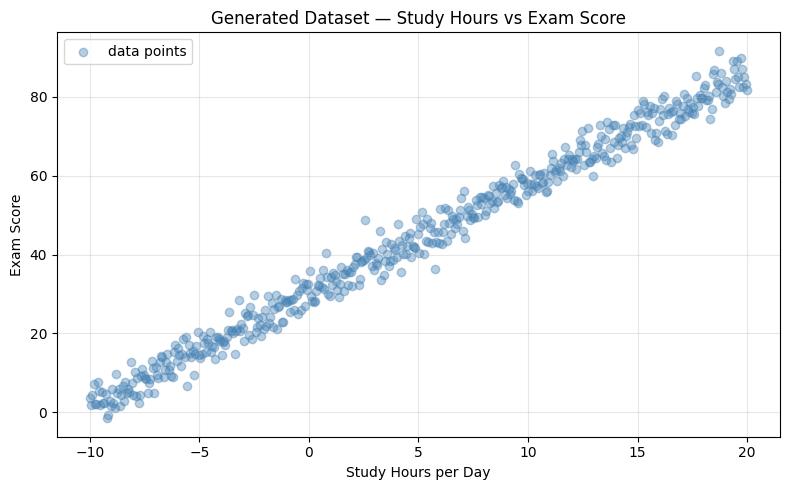

In [2]:
X, y = generate_linear_data()

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"X range : {X.min():.2f} to {X.max():.2f}")
print(f"y range : {y.min():.2f} to {y.max():.2f}")

# plot the raw data
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X, y, alpha=0.4, color="steelblue", label="data points")
ax.set_xlabel("Study Hours per Day")
ax.set_ylabel("Exam Score")
ax.set_title("Generated Dataset — Study Hours vs Exam Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 2 — Preprocessing

Three steps applied in order:
1. **Train/test split** — 80% train, 20% test
2. **Normalization** — mean=0, std=1 (fit on train only)
3. **Bias absorption** — prepend column of ones to X

In [3]:
X_train, X_test, y_train, y_test, mean, std = preprocess(X, y)

print(f"X_train shape : {X_train.shape}")   # (400, 2)
print(f"X_test  shape : {X_test.shape}")    # (100, 2)
print(f"y_train shape : {y_train.shape}")   # (400,)
print(f"y_test  shape : {y_test.shape}")    # (100,)

print(f"\nFirst row of X_train : {X_train[0]}")
print(f"  col 0 = {X_train[0,0]:.1f}  ← bias column (always 1.0)")
print(f"  col 1 = {X_train[0,1]:.4f}  ← normalized feature")

X_train shape : (400, 2)
X_test  shape : (100, 2)
y_train shape : (400,)
y_test  shape : (100,)

First row of X_train : [1.         0.78877946]
  col 0 = 1.0  ← bias column (always 1.0)
  col 1 = 0.7888  ← normalized feature


## Step 3 — Train All Three Optimizers

| Method | Samples per update | Updates per epoch |
|---|---|---|
| Batch GD | all 400 | 1 |
| Stochastic GD | 1 | 400 |
| Mini-Batch GD | 32 | 400/32 = 12 |

All start from `w = [0, 0]` for fair comparison.

In [4]:
import time

models = {
    "Batch GD"      : BatchGD(),
    "Stochastic GD" : StochasticGD(),
    "Mini-Batch GD" : MiniBatchGD(),
}

timings = {}
for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    timings[name] = time.time() - start
    print(f"  done in {timings[name]:.3f}s — {len(model.loss_history)} epochs\n")

Training Batch GD...
epoch    0 loss: 2502.6654
epoch  100 loss: 343.2258
epoch  200 loss: 53.9048
epoch  300 loss: 15.1417
epoch  400 loss: 9.9482
epoch  500 loss: 9.2524
epoch  600 loss: 9.1592
epoch  700 loss: 9.1467
epoch  800 loss: 9.1450
Converged at epoch 883
  done in 0.026s — 884 epochs

Training Stochastic GD...
epoch    0  loss: 9.9636
epoch  100  loss: 9.1582
epoch  200  loss: 9.1891
epoch  300  loss: 9.1457
epoch  400  loss: 9.2399
epoch  500  loss: 9.1533
epoch  600  loss: 9.2068
epoch  700  loss: 9.1917
epoch  800  loss: 9.1943
epoch  900  loss: 9.1962
  done in 2.815s — 1000 epochs

Training Mini-Batch GD...
epoch    0  loss: 1931.4101
Converged at epoch 86
  done in 0.011s — 87 epochs



## Step 4 — Loss Curves

Tracks MSE at every epoch.

- **Batch GD** — smooth but slow
- **Stochastic GD** — instant convergence but noisy
- **Mini-Batch GD** — fast and stable

Training Batch GD...
epoch    0 loss: 2502.6654
epoch  100 loss: 343.2258
epoch  200 loss: 53.9048
epoch  300 loss: 15.1417
epoch  400 loss: 9.9482
epoch  500 loss: 9.2524
epoch  600 loss: 9.1592
epoch  700 loss: 9.1467
epoch  800 loss: 9.1450
Converged at epoch 883
Training Stochastic GD...
epoch    0  loss: 9.9636
epoch  100  loss: 9.1582
epoch  200  loss: 9.1891
epoch  300  loss: 9.1457
epoch  400  loss: 9.2399
epoch  500  loss: 9.1533
epoch  600  loss: 9.2068
epoch  700  loss: 9.1917
epoch  800  loss: 9.1943
epoch  900  loss: 9.1962
Training Mini-Batch GD...
epoch    0  loss: 1931.4101
Converged at epoch 86
saved to results/loss_curves.png


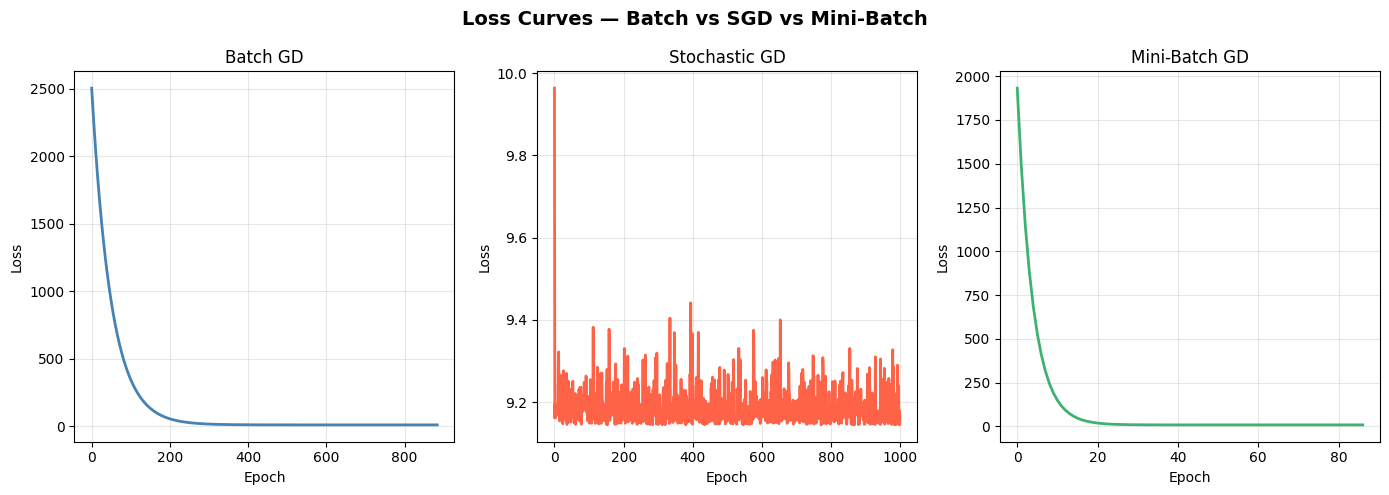

In [5]:
from visualizations.loss_curves import plot_loss_curves

plot_loss_curves()

## Step 5 — Weight Trajectory on Loss Surface

- **Background** = MSE loss at every possible weight combination
- **Path** = how weights moved during training
- **⚪ White dot** = starting weights `[0, 0]`
- **⭐ Yellow star** = final learned weights

Training Batch GD...
epoch    0 loss: 2502.6654
epoch  100 loss: 343.2258
epoch  200 loss: 53.9048
epoch  300 loss: 15.1417
epoch  400 loss: 9.9482
epoch  500 loss: 9.2524
epoch  600 loss: 9.1592
epoch  700 loss: 9.1467
epoch  800 loss: 9.1450
Converged at epoch 883
Training Stochastic GD...
epoch    0  loss: 9.9636
epoch  100  loss: 9.1582
epoch  200  loss: 9.1891
epoch  300  loss: 9.1457
epoch  400  loss: 9.2399
epoch  500  loss: 9.1533
epoch  600  loss: 9.2068
epoch  700  loss: 9.1917
epoch  800  loss: 9.1943
epoch  900  loss: 9.1962
Training Mini-Batch GD...
epoch    0  loss: 1931.4101
Converged at epoch 86
w_final: [43.56285033 24.39483603]
Saved to results/weight_trajectory.png


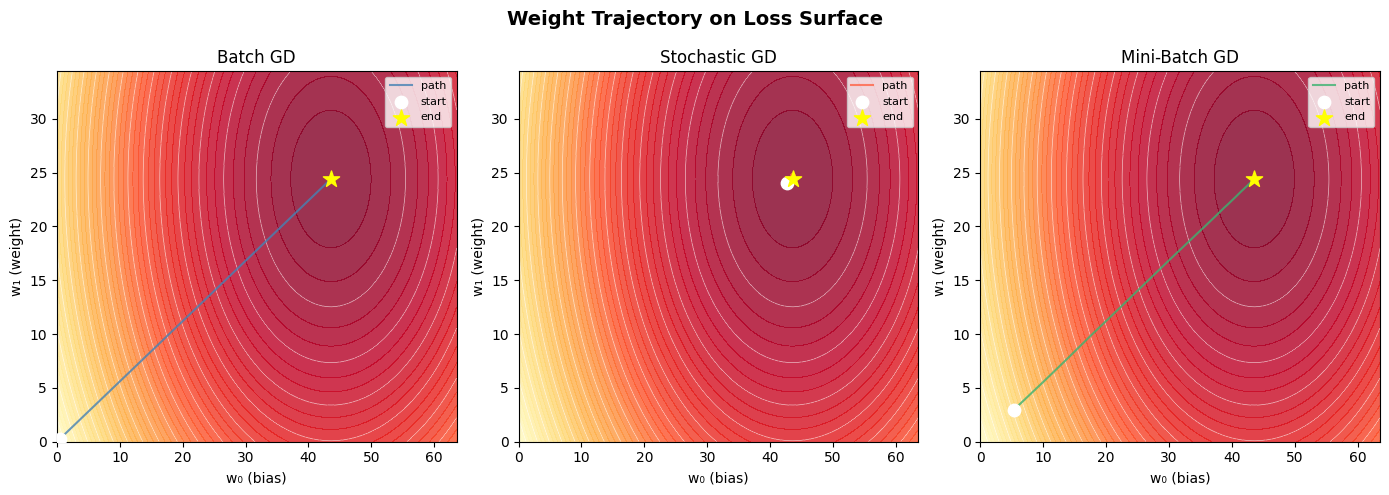

In [6]:
from visualizations.weight_trajectory import plot_weight_trajectory

plot_weight_trajectory()

## Step 6 — Final Evaluation

All models evaluated on the **held-out test set** (100 samples never seen during training).

Training Batch GD...
epoch    0 loss: 2502.6654
epoch  100 loss: 343.2258
epoch  200 loss: 53.9048
epoch  300 loss: 15.1417
epoch  400 loss: 9.9482
epoch  500 loss: 9.2524
epoch  600 loss: 9.1592
epoch  700 loss: 9.1467
epoch  800 loss: 9.1450
Converged at epoch 883
Training Stochastic GD...
epoch    0  loss: 9.9636
epoch  100  loss: 9.1582
epoch  200  loss: 9.1891
epoch  300  loss: 9.1457
epoch  400  loss: 9.2399
epoch  500  loss: 9.1533
epoch  600  loss: 9.2068
epoch  700  loss: 9.1917
epoch  800  loss: 9.1943
epoch  900  loss: 9.1962
Training Mini-Batch GD...
epoch    0  loss: 1931.4101
Converged at epoch 86


Optimizer            MSE     RMSE      MAE       R²   Epochs  Time(s)
Batch GD          6.6578   2.5803   2.0731   0.9887      884   0.0159
Stochastic GD     6.6092   2.5708   2.0705   0.9888     1000   2.8524
Mini-Batch GD     6.6566   2.5800   2.0730   0.9887       87   0.0110

🏆 Best R²     : Stochastic GD
⚡ Fastest     : Mini-Batch GD
📉 Fewest epochs: Mini-Batch GD

Saved 

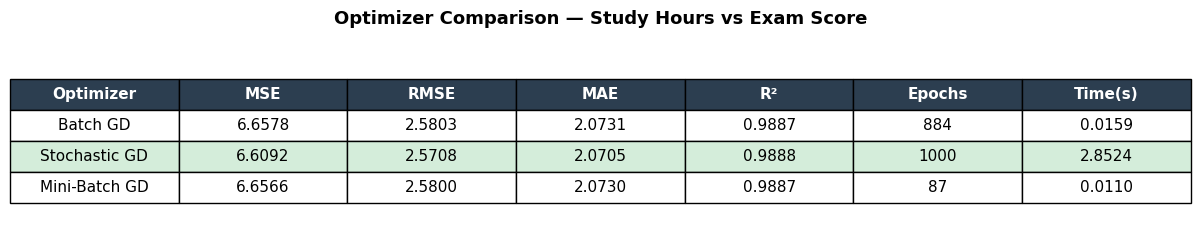

{'Batch GD': {'mse': np.float64(6.657845837185658),
  'rmse': np.float64(2.580280185791004),
  'mae': np.float64(2.0731455081729404),
  'r2': np.float64(0.9886935958691381),
  'epochs': 884,
  'time': 0.015888214111328125},
 'Stochastic GD': {'mse': np.float64(6.609227846419264),
  'rmse': np.float64(2.570841855583354),
  'mae': np.float64(2.070504000749258),
  'r2': np.float64(0.9887761593085865),
  'epochs': 1000,
  'time': 2.852416753768921},
 'Mini-Batch GD': {'mse': np.float64(6.656553660371353),
  'rmse': np.float64(2.580029778969877),
  'mae': np.float64(2.073033499478388),
  'r2': np.float64(0.9886957902535725),
  'epochs': 87,
  'time': 0.011044740676879883}}

In [7]:
from visualizations.comparison_table import run_comparison

run_comparison()

## Conclusion

All three optimizers successfully learned the relationship between
study hours and exam scores — achieving **R² ≈ 0.98**.

| Optimizer | Best for |
|---|---|
| **Batch GD** | Small datasets. It's stable and exact |
| **Stochastic GD** | Very large datasets. It's memory efficient |
| **Mini-Batch GD** | Everything. It's the best balance of speed and stability |